In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
from openbb import obb
import yfinance as yf
import riskfolio as rp

In [3]:
pd.options.display.float_format = '{:.4%}'.format
# Date range
start_date = ('2020-09-30')
end_date = ('2024-09-30')

In [22]:
assets=['IWVL.L', 'ACWI'] 
assets.sort()

In [23]:
# Tickers of factors
factors = ['MTUM', 'QUAL', 'VLUE', 'SIZE', 'USMV']
factors.sort()
tickers=assets+factors
print(tickers)



['ACWI', 'IWVL.L', 'MTUM', 'QUAL', 'SIZE', 'USMV', 'VLUE']


In [24]:
data = data = yf.download(tickers, 
start=start_date, 
end=end_date, interval='1mo')['Adj Close']

data = data.dropna()



[*********************100%%**********************]  7 of 7 completed


In [25]:
print(data.tail())

                  ACWI     IWVL.L        MTUM        QUAL        SIZE  \
Date                                                                    
2024-05-01 11015.5243% 4302.0000% 18600.2914% 16489.9826% 13700.4364%   
2024-06-01 11146.4256% 4241.5001% 19424.6460% 16989.4379% 13653.7766%   
2024-07-01 11412.9997% 4411.0001% 19055.6076% 17125.9171% 14259.5062%   
2024-08-01 11698.0003% 4424.0002% 19694.2200% 17724.0982% 14622.9889%   
2024-09-01 11955.0003% 4484.9998% 20232.0526% 17875.6378% 14817.1783%   

                 USMV        VLUE  
Date                               
2024-05-01 8213.2751% 10271.0854%  
2024-06-01 8328.3401% 10206.9580%  
2024-07-01 8665.1764% 10675.2594%  
2024-08-01 9091.2674% 10718.9171%  
2024-09-01 9090.2710% 10819.1307%  


In [27]:
X = data[factors].pct_change().dropna()
Y = data[assets].pct_change().dropna()
Y['Active']=Y['IWVL.L']-Y['ACWI']
display(Y.head())

,ACWI,IWVL.L,Active
Date,,,
2020-11-01,11.7610%,16.6409%,4.8799%
2020-12-01,3.8818%,4.4127%,0.5309%
2021-01-01,0.4643%,1.9701%,1.5058%
2021-02-01,2.2888%,6.0143%,3.7255%
2021-03-01,2.8537%,5.5556%,2.7018%


In [28]:
#This part is just to visualize how Riskfolio-Lib calculates a loadings matrix.
step = 'Forward' # Could be Forward or Backward stepwise regression
loadings = rp.loadings_matrix(X=X, Y=Y, stepwise=step)

loadings.style.format("{:.4f}").background_gradient(cmap='RdYlGn')

,const,MTUM,QUAL,SIZE,USMV,VLUE
ACWI,-0.0005,0.0000,0.4762,0.4122,0.0000,0.0000
IWVL.L,0.0033,0.0000,0.0000,0.0000,0.0000,0.7808
Active,0.0044,0.0000,-0.7113,0.0000,0.0000,0.5880


In [29]:
print(loadings)

          const    MTUM      QUAL     SIZE    USMV     VLUE
ACWI   -0.0454% 0.0000%  47.6212% 41.2191% 0.0000%  0.0000%
IWVL.L  0.3273% 0.0000%   0.0000%  0.0000% 0.0000% 78.0765%
Active  0.4426% 0.0000% -71.1281%  0.0000% 0.0000% 58.7966%


In [30]:
import statsmodels.api as sm

In [36]:
# Prepare the independent variables (add a constant to the model)
x = sm.add_constant(X[['MTUM', 'QUAL', 'VLUE', 'SIZE', 'USMV']])
# The dependent variable
y = Y["IWVL.L"]
# Run the regression
model = sm.OLS(y, x).fit()
# Display the summary of the regression
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 IWVL.L   R-squared:                       0.887
Model:                            OLS   Adj. R-squared:                  0.873
Method:                 Least Squares   F-statistic:                     64.21
Date:                Sun, 13 Oct 2024   Prob (F-statistic):           2.60e-18
Time:                        22:39:28   Log-Likelihood:                 128.55
No. Observations:                  47   AIC:                            -245.1
Df Residuals:                      41   BIC:                            -234.0
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0037      0.003      1.445      0.1

In [37]:
# Step 5.2: Plot the coefficients and their confidence intervals
factors = model.params.index[1:]  # ['Mkt_Rf', 'SMB', 'HML']
coefficients = model.params.values[1:]
confidence_intervals = model.conf_int().diff(axis=1).iloc[1]

In [38]:
# Create a DataFrame
ols_data = pd.DataFrame(
    {
        "Factor": factors,
        "Coefficient": coefficients,
        "Confidence_Lower": confidence_intervals[0],
        "Confidence_Upper": confidence_intervals[1],
    }
)

In [39]:
import matplotlib.pyplot as plt
import matplotlib.style as style
import seaborn as sns

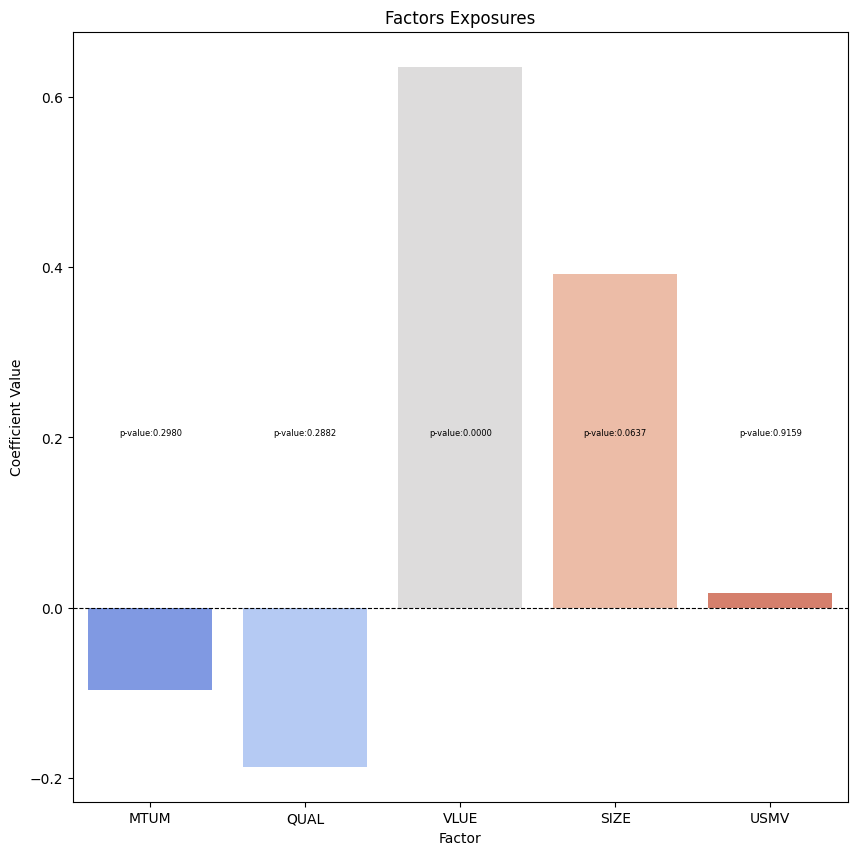

In [42]:


# Plotting
plt.figure(figsize=(10, 10))
sns.barplot(x="Factor", y="Coefficient", data=ols_data, capsize=0.2, palette="coolwarm")

# Add the p-value for each factor to the plot
for i, row in ols_data.iterrows():
    plt.text(
        i,
        0.2,
        f"p-value:{model.pvalues[row['Factor']]:.4f}",
        ha="center",
        va="bottom",
        fontsize=6,
    )

plt.title("Factors Exposures")
plt.xlabel("Factor"); plt.ylabel("Coefficient Value")
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.show()